# 05 — Segment Profiling

Characterize the K-Means segments from nb 04 and contrast them with the
rule-based RFM segments from nb 03.

Deliverables: a segment summary table, customer-vs-revenue concentration,
RFM distributions, a snake plot of mean RFM scores, a standardized profile
heatmap, the K-Means-vs-quintile cross-tab, and top products per segment.

> Scope note: the dataset is filtered to the UK, so per-country profiling is
> not applicable; product-level profiling replaces it.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import load_settings
from src.viz import set_style

set_style()

ROOT = Path.cwd().parent
settings = load_settings(ROOT / "config" / "settings.yaml")

FIG_DIR = ROOT / settings["paths"]["reports"] / "figures"
TBL_DIR = ROOT / settings["paths"]["reports"] / "tables"
GOLD = ROOT / settings["paths"]["gold"]

# Value order, best -> worst, for consistent sorting and plotting.
ORDER = ["Champions", "Loyal", "Potential", "At Risk", "Hibernating", "Lost"]


def savefig(fig, name):
    fig.savefig(FIG_DIR / f"05_{name}.png", dpi=150, bbox_inches="tight")


def savetable(df, name):
    df.to_csv(TBL_DIR / f"05_{name}.csv")

In [2]:
segments = pd.read_parquet(GOLD / "customer_segments.parquet")
rfm = pd.read_parquet(GOLD / "rfm_table.parquet")
tx = pd.read_parquet(ROOT / settings["paths"]["silver"] / "transactions_clean.parquet")

# Bring the quintile segment + R/F/M scores alongside the K-Means labels.
seg = segments.merge(
    rfm[["Customer ID", "R_score", "F_score", "M_score", "Segment"]],
    on="Customer ID", how="left",
)
present = [s for s in ORDER if s in seg["ClusterLabel"].unique()]
seg["ClusterLabel"] = pd.Categorical(seg["ClusterLabel"], categories=present, ordered=True)
seg.shape

(5336, 10)

## 1. Segment summary

In [3]:
summary = (
    seg.groupby("ClusterLabel", observed=True)
    .agg(
        customers=("Customer ID", "size"),
        recency_mean=("Recency", "mean"),
        frequency_mean=("Frequency", "mean"),
        monetary_mean=("Monetary", "mean"),
        monetary_median=("Monetary", "median"),
        revenue_total=("Monetary", "sum"),
    )
)
summary["customer_pct"] = (summary["customers"] / summary["customers"].sum() * 100)
summary["revenue_pct"] = (summary["revenue_total"] / summary["revenue_total"].sum() * 100)
summary = summary[[
    "customers", "customer_pct", "recency_mean", "frequency_mean",
    "monetary_mean", "monetary_median", "revenue_total", "revenue_pct",
]]
savetable(summary, "segment_summary")
summary.round(1)

,customers,customer_pct,recency_mean,frequency_mean,monetary_mean,monetary_median,revenue_total,revenue_pct
ClusterLabel,,,,,,,,
Champions,1028,19.3,25.4,19.6,9441.3,4842.2,9705684.4,71.0
Loyal,1128,21.1,27.7,3.1,817.7,705.5,922405.7,6.7
Potential,1334,25.0,220.8,5.4,1854.8,1441.7,2474261.8,18.1
At Risk,1846,34.6,394.1,1.4,305.4,258.6,563855.0,4.1


## 2. Customer share vs. revenue share

The gap between how many customers a segment holds and how much revenue it
generates is the core argument for differentiated treatment.

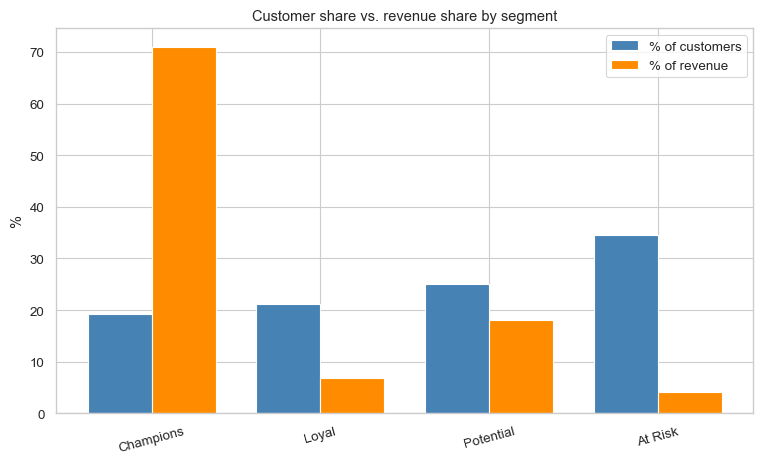

In [4]:
shares = summary[["customer_pct", "revenue_pct"]]
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(shares))
w = 0.38
ax.bar(x - w / 2, shares["customer_pct"], w, label="% of customers", color="steelblue")
ax.bar(x + w / 2, shares["revenue_pct"], w, label="% of revenue", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(shares.index, rotation=15)
ax.set_ylabel("%")
ax.set_title("Customer share vs. revenue share by segment")
ax.legend()
savefig(fig, "share_vs_revenue")
plt.show()

## 3. RFM distributions by segment

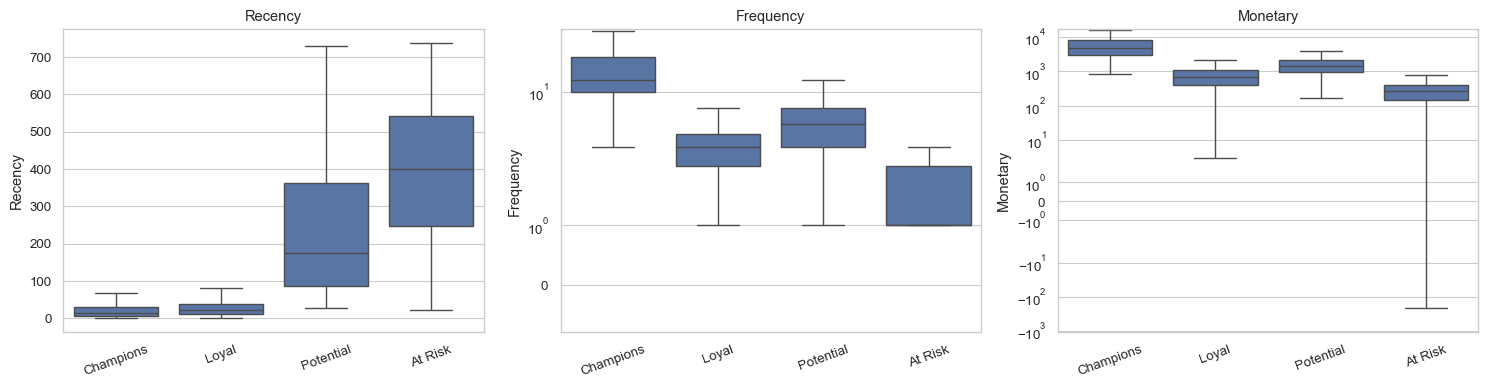

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
order = list(seg["ClusterLabel"].cat.categories)
for ax, col, logy in zip(axes, ["Recency", "Frequency", "Monetary"], [False, True, True]):
    sns.boxplot(data=seg, x="ClusterLabel", y=col, order=order, ax=ax, showfliers=False)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    if logy:
        ax.set_yscale("symlog")
    ax.set_title(col)
fig.tight_layout()
savefig(fig, "rfm_boxplots")
plt.show()

## 4. Snake plot

Mean R/F/M *quintile scores* (1–5) per segment — the standard RFM profile
fingerprint. A high R score means recent; high F/M mean frequent / high-spend.

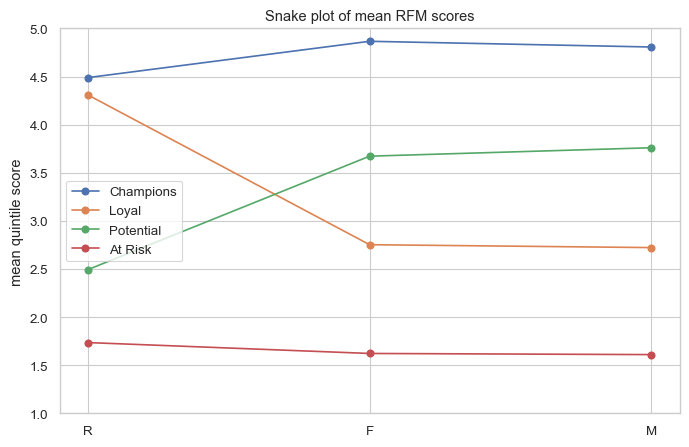

,R_score,F_score,M_score
ClusterLabel,,,
Champions,4.49,4.87,4.81
Loyal,4.31,2.75,2.72
Potential,2.49,3.67,3.76
At Risk,1.74,1.62,1.61


In [6]:
score_means = seg.groupby("ClusterLabel", observed=True)[["R_score", "F_score", "M_score"]].mean()
fig, ax = plt.subplots(figsize=(8, 5))
for label, row in score_means.iterrows():
    ax.plot(["R", "F", "M"], row.values, marker="o", label=label)
ax.set_ylim(1, 5)
ax.set_ylabel("mean quintile score")
ax.set_title("Snake plot of mean RFM scores")
ax.legend()
savefig(fig, "snake_plot")
plt.show()
score_means.round(2)

## 5. Standardized profile heatmap

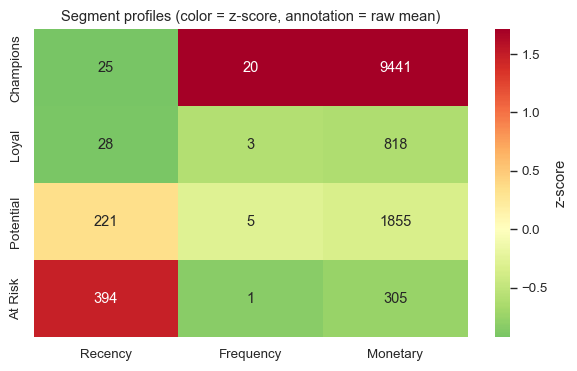

In [7]:
profile = seg.groupby("ClusterLabel", observed=True)[["Recency", "Frequency", "Monetary"]].mean()
z = (profile - profile.mean()) / profile.std(ddof=0)
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(z, annot=profile.round(0), fmt=".0f", cmap="RdYlGn_r", center=0,
            cbar_kws={"label": "z-score"}, ax=ax)
ax.set_title("Segment profiles (color = z-score, annotation = raw mean)")
ax.set_xlabel("")
ax.set_ylabel("")
savefig(fig, "profile_heatmap")
plt.show()

## 6. K-Means vs. rule-based quintile segments

Row-normalized: for each K-Means segment, the share of its members falling into
each traditional RFM segment.

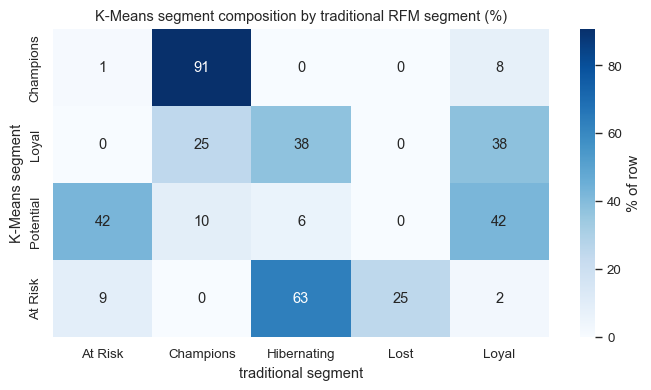

Segment,At Risk,Champions,Hibernating,Lost,Loyal
ClusterLabel,,,,,
Champions,12,934,0,0,82
Loyal,0,278,424,0,426
Potential,564,127,78,3,562
At Risk,170,0,1167,463,46


In [8]:
xtab = pd.crosstab(seg["ClusterLabel"], seg["Segment"])
xtab_norm = xtab.div(xtab.sum(axis=1), axis=0) * 100
savetable(xtab, "kmeans_vs_quintile_counts")
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(xtab_norm, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "% of row"}, ax=ax)
ax.set_title("K-Means segment composition by traditional RFM segment (%)")
ax.set_xlabel("traditional segment")
ax.set_ylabel("K-Means segment")
savefig(fig, "kmeans_vs_quintile")
plt.show()
xtab

## 7. Top products per segment

Joining silver purchases to the K-Means labels, the highest-revenue products
within each segment.

In [9]:
purch = tx[~tx["Invoice"].str.startswith("C")].merge(
    seg[["Customer ID", "ClusterLabel"]], on="Customer ID", how="inner"
)
TOP_N = 10
rows = []
for label in seg["ClusterLabel"].cat.categories:
    top = (purch[purch["ClusterLabel"] == label]
           .groupby("Description")["Revenue"].sum()
           .nlargest(TOP_N))
    for rank, (desc, rev) in enumerate(top.items(), 1):
        rows.append({"segment": label, "rank": rank, "product": desc, "revenue": round(rev, 2)})
top_products = pd.DataFrame(rows)
savetable(top_products.set_index(["segment", "rank"]), "top_products_per_segment")
top_products.pivot(index="rank", columns="segment", values="product")

segment,At Risk,Champions,Loyal,Potential
rank,,,,
1,MEDIUM CERAMIC TOP STORAGE JAR,REGENCY CAKESTAND 3 TIER,"PAPER CRAFT , LITTLE BIRDIE",WHITE HANGING HEART T-LIGHT HOLDER
2,WHITE HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,REGENCY CAKESTAND 3 TIER,PICNIC BASKET WICKER 60 PIECES
3,REGENCY CAKESTAND 3 TIER,JUMBO BAG RED RETROSPOT,WHITE HANGING HEART T-LIGHT HOLDER,REGENCY CAKESTAND 3 TIER
4,VINTAGE UNION JACK BUNTING,ASSORTED COLOUR BIRD ORNAMENT,ASSORTED COLOUR BIRD ORNAMENT,PARTY BUNTING
5,PARTY BUNTING,PARTY BUNTING,PAPER CHAIN KIT 50'S CHRISTMAS,ASSORTED COLOUR BIRD ORNAMENT
6,ASSORTED COLOUR BIRD ORNAMENT,CHILLI LIGHTS,BAKING SET 9 PIECE RETROSPOT,FAIRY CAKE FLANNEL ASSORTED COLOUR
7,BAKING SET 9 PIECE RETROSPOT,PAPER CHAIN KIT 50'S CHRISTMAS,METAL SIGN TAKE IT OR LEAVE IT,JUMBO BAG RED RETROSPOT
8,ANTIQUE SILVER TEA GLASS ENGRAVED,BLACK RECORD COVER FRAME,HOT WATER BOTTLE KEEP CALM,GIN + TONIC DIET METAL SIGN
9,GRAND CHOCOLATECANDLE,JUMBO BAG STRAWBERRY,PAPER CHAIN KIT VINTAGE CHRISTMAS,VINTAGE UNION JACK BUNTING


## 8. Save gold/segment_summary.parquet

In [10]:
out_path = GOLD / "segment_summary.parquet"
summary.reset_index().to_parquet(out_path, index=False)
print(f"saved: {out_path}")

saved: D:\disertatie v2\Customer Behavior Analysis\data\gold\segment_summary.parquet


## Key findings

- **Value concentration.** A minority of customers (Champions) generate a
  disproportionate share of revenue, while the largest segment by headcount
  (At Risk) contributes the least — the central case for differentiated CRM.
- **Distinct fingerprints.** The snake plot and standardized heatmap show each
  segment occupies a clearly different region of RFM space, confirming the
  clusters are interpretable rather than arbitrary.
- **Agreement with the baseline.** The row-normalized cross-tab shows the
  K-Means segments map coherently onto the traditional RFM segments at the
  extremes, while reallocating the ambiguous middle.
- **Actionability.** Top-product tables per segment provide concrete assortment
  and targeting hooks, and feed naturally into the market-basket analysis (nb 06).